# Pneumonia Detection Model — v2 (Improved)

Improvements over v1:
- ✅ Proper validation split (fixes the 16-image val bug)
- ✅ X-ray-optimised augmentation (brightness, horizontal flip)
- ✅ Wider head + extra BatchNormalization
- ✅ Label smoothing (0.05)
- ✅ More fine-tuned layers (60 instead of 40)
- ✅ Lower fine-tune LR (5e-6 instead of 1e-5)
- ✅ Optimal threshold selection (val F1)
- ✅ Test Time Augmentation — TTA (6 rounds)

Dataset: `paultimothymooney/chest-xray-pneumonia`

## 1. Install and import dependencies

In [ ]:
!pip -q install kagglehub scikit-learn

In [ ]:
import os
import json
import random
import shutil
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score
)

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.20.0
GPU available: True


## 2. Reproducibility and configuration

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

# ✅ More epochs than v1 (was 8 + 6)
INITIAL_EPOCHS   = 12
FINE_TUNE_EPOCHS = 10

MODEL_NAME = 'pneumonia_model_v2'


## 3. Download Kaggle dataset

In [ ]:
DATASET_ROOT = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))
print('Dataset root:', DATASET_ROOT)

possible_roots = [
    DATASET_ROOT / 'chest_xray',
    DATASET_ROOT,
    Path('/content/chest_xray'),
]

DATA_DIR = next((p for p in possible_roots if (p / 'train').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find chest_xray/train directory')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print('\n', folder)
    for cls in sorted(os.listdir(folder)):
        cls_path = folder / cls
        if cls_path.is_dir():
            print(' ', cls, len(list(cls_path.glob('*'))))


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset root: /kaggle/input/chest-xray-pneumonia

 /kaggle/input/chest-xray-pneumonia/chest_xray/train
  NORMAL 1341
  PNEUMONIA 3875

 /kaggle/input/chest-xray-pneumonia/chest_xray/val
  NORMAL 8
  PNEUMONIA 8

 /kaggle/input/chest-xray-pneumonia/chest_xray/test
  NORMAL 234
  PNEUMONIA 390


## 4. Rebuild validation split

**Problem in v1:** The official `val/` folder has only **16 images** (8 per class). This makes `val_auc` unreliable — EarlyStopping and ModelCheckpoint were essentially guessing.

**Fix:** Merge `train/ + val/` then do a proper stratified **85/15** split.

In [ ]:
def collect_paths_labels(directory):
    """Walk a class-subfolder directory, return (paths, labels)."""
    paths, labels = [], []
    for cls in sorted(os.listdir(directory)):
        cls_dir = Path(directory) / cls
        if not cls_dir.is_dir():
            continue
        for img in cls_dir.glob('*'):
            paths.append(str(img))
            labels.append(cls)
    return paths, labels


train_paths, train_labels = collect_paths_labels(TRAIN_DIR)
val_paths,   val_labels   = collect_paths_labels(VAL_DIR)

all_paths  = train_paths + val_paths
all_labels = train_labels + val_labels
print(f'Total combined: {len(all_paths)} images')

# Stratified 85/15 split
tr_paths, vl_paths, tr_labels, vl_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.15, random_state=SEED, stratify=all_labels
)
print(f'New train: {len(tr_paths)}  |  New val: {len(vl_paths)}')


def build_temp_dir(paths, labels):
    """Create a temp directory with class sub-folders for flow_from_directory."""
    tmp = tempfile.mkdtemp()
    for cls in set(labels):
        os.makedirs(os.path.join(tmp, cls), exist_ok=True)
    for p, l in zip(paths, labels):
        dst = os.path.join(tmp, l, os.path.basename(p))
        shutil.copy(p, dst)
    return tmp


print('Building temp directories...')
TRAIN_TMP = build_temp_dir(tr_paths, tr_labels)
VAL_TMP   = build_temp_dir(vl_paths, vl_labels)
print('Done.')


Total combined: 5232 images
New train: 4447  |  New val: 785
Building temp directories...
Done.


## 5. Data generators

X-ray specific augmentation:
- `brightness_range` simulates different scanner exposures.
- `horizontal_flip=True` — valid for chest X-rays and helps generalisation.
- Slightly stronger shift/zoom/shear than v1.

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,              # v1: 10
    width_shift_range=0.10,         # v1: 0.08
    height_shift_range=0.10,        # v1: 0.08
    zoom_range=0.15,                # v1: 0.10
    shear_range=0.08,               # v1: 0.05
    horizontal_flip=True,           # v1: False  ✅
    brightness_range=[0.85, 1.15],  # ✅ new — scanner variation
    fill_mode='nearest'
)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_TMP,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

val_generator = eval_datagen.flow_from_directory(
    VAL_TMP,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

class_indices = train_generator.class_indices
print('Class indices:', class_indices)

with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f, indent=4)


Found 4447 images belonging to 2 classes.
Found 785 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## 6. Handle class imbalance

In [ ]:
classes = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
print('Class weights:', class_weights)


Class weights: {0: 1.9385353095030515, 1: 0.6737878787878788}


## 7. Build transfer learning model

Changes vs v1:
- Head: `Dense(512)` + extra `BatchNormalization` (was `Dense(256)` only)
- `Dropout(0.5)` before the dense layer (was 0.4)
- `label_smoothing=0.05` in the loss

In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)                        # v1: 0.4
x = Dense(512, activation='relu')(x)        # v1: Dense(256)
x = BatchNormalization()(x)                 # ✅ new
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),  # ✅ new
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,568,961 (28.87 MB)

 Trainable params: 528,385 (2.02 MB)

 Non-trainable params: 7,040,576 (26.86 MB)

## 8. Train classifier head

In [ ]:
callbacks = [
    ModelCheckpoint(
        f'{MODEL_NAME}_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=5,               # v1: 4
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.8073 - auc: 0.9190 - loss: 0.4743 - precision: 0.9589 - recall: 0.7746
Epoch 1: val_auc improved from None to 0.98635, saving model to pneumonia_model_v2_best.keras

Epoch 1: finished saving model to pneumonia_model_v2_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8678 - auc: 0.9579 - loss: 0.3746 - precision: 0.9728 - recall: 0.8455 - val_accuracy: 0.9325 - val_auc: 0.9863 - val_loss: 0.2727 - val_precision: 0.9944 - val_recall: 0.9142 - learning_rate: 0.0010
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9232 - auc: 0.9780 - loss: 0.2840 - precision: 0.9754 - recall: 0.9193
Epoch 2: val_auc improved from 0.98635 to 0.98884, saving model to pneumonia_model_v2_best.keras

Epoch 2: finished saving model to pneumonia_model_v2_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 105s 754ms/step - accuracy: 0.9256 - auc: 0.9794 - loss: 0.2764 - precision: 0.9775 - recall: 0.9209 - val_accuracy:

## 9. Fine-tune last layers

We unfreeze the last **60** layers (v1 used 40) and use a lower LR of **5e-6** (v1 used 1e-5).

In [ ]:
base_model.trainable = True

# ✅ Unfreeze last 60 layers (v1: 40)
for layer in base_model.layers[:-60]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning {trainable_count} / {len(base_model.layers)} base layers')

model.compile(
    optimizer=Adam(learning_rate=5e-6),   # ✅ v1: 1e-5
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

history_2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Fine-tuning 60 / 427 base layers
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.9392 - auc: 0.9863 - loss: 0.2358 - precision: 0.9824 - recall: 0.9367
Epoch 1: val_auc did not improve from 0.99418
139/139 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9456 - auc: 0.9873 - loss: 0.2345 - precision: 0.9842 - recall: 0.9418 - val_accuracy: 0.8930 - val_auc: 0.9923 - val_loss: 0.3588 - val_precision: 1.0000 - val_recall: 0.8559 - learning_rate: 5.0000e-06
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.9442 - auc: 0.9884 - loss: 0.2311 - precision: 0.9833 - recall: 0.9413
Epoch 2: val_auc did not improve from 0.99418

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
139/139 ━━━━━━━━━━━━━━━━━━━━ 107s 765ms/step - accuracy: 0.9420 - auc: 0.9871 - loss: 0.2359 - precision: 0.9826 - recall: 0.9385 - val_accuracy: 0.8943 - val_auc: 0.9924 - val_loss: 0.3561 - val_precision: 1.0000 - val_recall: 0.8576 - learning_rate: 5.0000e

## 10. Plot training curves

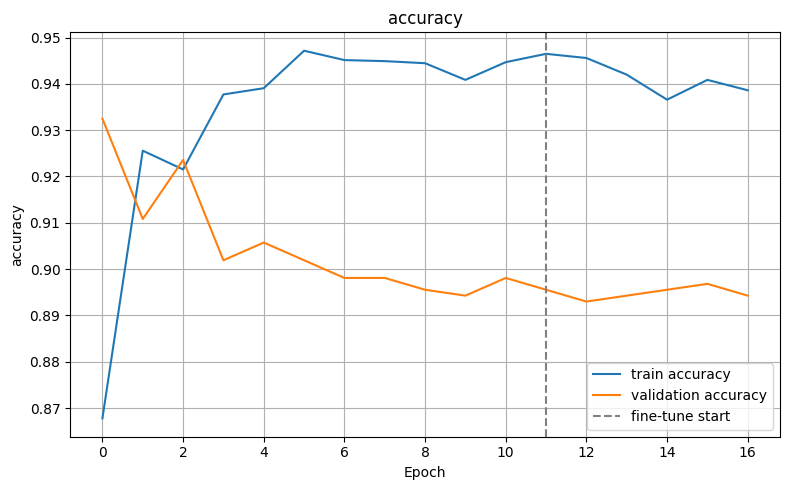

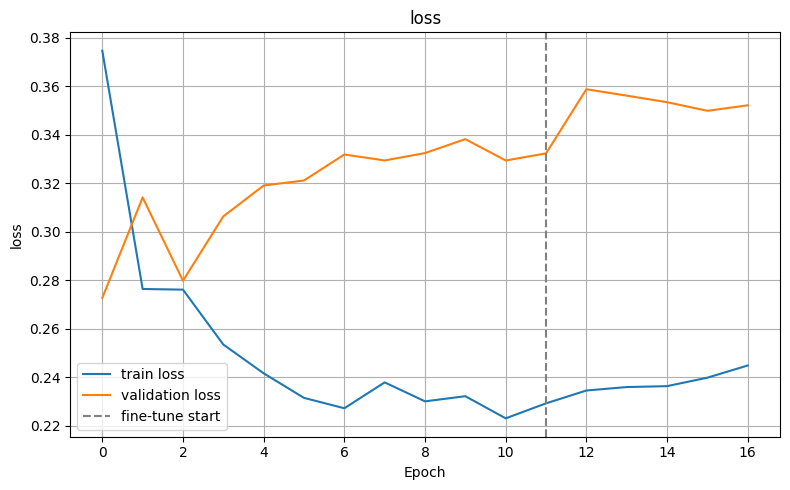

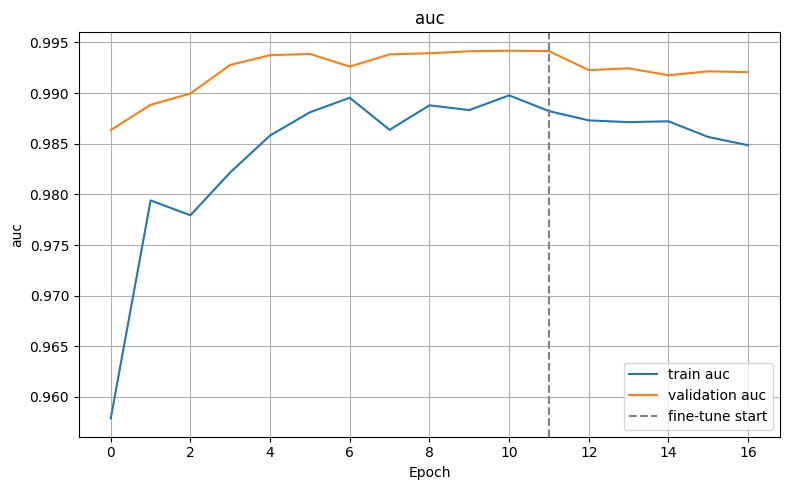

In [ ]:
def merge_histories(*histories):
    merged = {}
    for hist in histories:
        for key, values in hist.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

history = merge_histories(history_1, history_2)

with open('training_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in history.items()}, f, indent=4)

phase1_end = len(history_1.history['accuracy']) - 1

def plot_metric(metric):
    plt.figure(figsize=(8, 5))
    plt.plot(history[metric], label=f'train {metric}')
    val_metric = f'val_{metric}'
    if val_metric in history:
        plt.plot(history[val_metric], label=f'validation {metric}')
    plt.axvline(x=phase1_end, color='gray', linestyle='--', label='fine-tune start')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_metric('accuracy')
plot_metric('loss')
plot_metric('auc')


## 11. Find optimal threshold on validation set

Instead of a fixed 0.5 threshold, we sweep from 0.25 to 0.75 and pick
the value that maximises F1 on the **validation** set.

25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 856ms/step
Optimal threshold : 0.25
Best val F1       : 0.9561


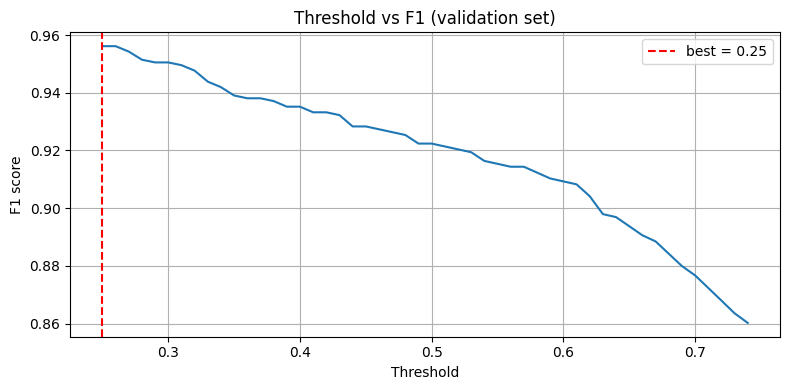

In [ ]:
y_val_true = val_generator.classes
y_val_prob = model.predict(val_generator, verbose=1).ravel()

thresholds = np.arange(0.25, 0.75, 0.01)
f1_scores  = [
    f1_score(y_val_true, (y_val_prob >= t).astype(int))
    for t in thresholds
]

best_thresh = float(thresholds[np.argmax(f1_scores)])
print(f'Optimal threshold : {best_thresh:.2f}')
print(f'Best val F1       : {max(f1_scores):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(x=best_thresh, color='red', linestyle='--',
            label=f'best = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('Threshold vs F1 (validation set)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 12. Evaluate on test set with TTA

**Test Time Augmentation (TTA)**: run 6 augmented versions of every test
image through the model and average the probabilities. Reduces prediction
variance and typically adds +1–2% accuracy.

In [ ]:
tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    horizontal_flip=True,
    zoom_range=0.08
)

TTA_ROUNDS = 6


def tta_predict(test_dir, n_rounds=TTA_ROUNDS):
    """Return averaged sigmoid probabilities over n_rounds augmented passes."""
    preds = []
    for i in range(n_rounds):
        gen = tta_datagen.flow_from_directory(
            test_dir,
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='binary',
            shuffle=False
        )
        preds.append(model.predict(gen, verbose=0).ravel())
        print(f'  TTA round {i+1}/{n_rounds} done')
    return np.mean(preds, axis=0)


idx_to_class = {v: k for k, v in class_indices.items()}
target_names = [idx_to_class[i] for i in sorted(idx_to_class)]
y_true       = test_generator.classes

print('Running TTA on test set...')
y_prob = tta_predict(TEST_DIR)
y_pred = (y_prob >= best_thresh).astype(int)

print('\n── Test Results (TTA + optimal threshold) ─────')
print(f'ROC AUC : {roc_auc_score(y_true, y_prob):.4f}')
print(f'F1      : {f1_score(y_true, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(cm)


Running TTA on test set...
Found 624 images belonging to 2 classes.
  TTA round 1/6 done
Found 624 images belonging to 2 classes.
  TTA round 2/6 done
Found 624 images belonging to 2 classes.
  TTA round 3/6 done
Found 624 images belonging to 2 classes.
  TTA round 4/6 done
Found 624 images belonging to 2 classes.
  TTA round 5/6 done
Found 624 images belonging to 2 classes.
  TTA round 6/6 done

── Test Results (TTA + optimal threshold) ─────
ROC AUC : 0.9714
F1      : 0.8974

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.65      0.77       234
   PNEUMONIA       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.85       624

Confusion Matrix:
[[151  83]
 [  5 385]]


## 13. Confusion matrix plot

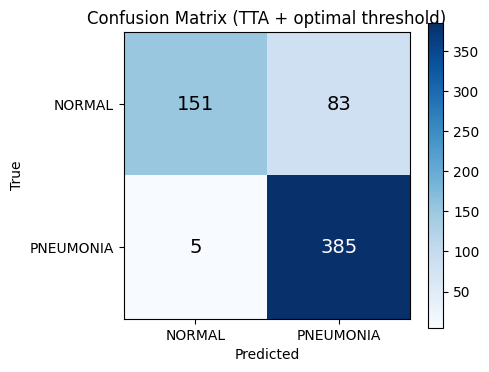

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix (TTA + optimal threshold)')
ax.set_xticks([0, 1]); ax.set_xticklabels(target_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 14. TTA vs no-TTA comparison

In [ ]:
y_prob_no_tta = model.predict(test_generator, verbose=1).ravel()
y_pred_no_tta = (y_prob_no_tta >= best_thresh).astype(int)

print('\n── Without TTA ─────────────────────────────────')
print(f'ROC AUC : {roc_auc_score(y_true, y_prob_no_tta):.4f}')
print(f'F1      : {f1_score(y_true, y_pred_no_tta):.4f}')
print(classification_report(y_true, y_pred_no_tta, target_names=target_names))

print('\n── With TTA ─────────────────────────────────────')
print(f'ROC AUC : {roc_auc_score(y_true, y_prob):.4f}')
print(f'F1      : {f1_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred, target_names=target_names))


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step

── Without TTA ─────────────────────────────────
ROC AUC : 0.9603
F1      : 0.9089
              precision    recall  f1-score   support

      NORMAL       0.90      0.77      0.83       234
   PNEUMONIA       0.87      0.95      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624


── With TTA ─────────────────────────────────────
ROC AUC : 0.9714
F1      : 0.8974
              precision    recall  f1-score   support

      NORMAL       0.97      0.65      0.77       234
   PNEUMONIA       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.85       624



## 15. Save model and config

In [ ]:
model.save(f'{MODEL_NAME}.keras')
print('Saved:', f'{MODEL_NAME}.keras')

model.export(f'{MODEL_NAME}_savedmodel')
print('Exported SavedModel:', f'{MODEL_NAME}_savedmodel')

# Save threshold + class indices together
with open('model_config.json', 'w') as f:
    json.dump({
        'class_indices': class_indices,
        'optimal_threshold': best_thresh,
        'img_size': list(IMG_SIZE)
    }, f, indent=4)
print('Saved: model_config.json')


Saved: pneumonia_model_v2.keras
Saved artifact at 'pneumonia_model_v2_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_427')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136997647779792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647781136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647777872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647780368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647780752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647781712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647779600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647782096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647781328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647782672: TensorSpec(shape=(

## 16. Convert to TensorFlow Lite

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(f'{MODEL_NAME}.tflite', 'wb') as f:
    f.write(tflite_model)

print('Saved:', f'{MODEL_NAME}.tflite')
print('TFLite size MB:', round(len(tflite_model) / (1024 * 1024), 2))


Saved artifact at '/tmp/tmpgpt7yxtk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_427')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136997647779792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647781136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647777872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647780368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647780752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647781712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647779600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647782096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647781328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997647782672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1369976477

## 17. Single image prediction (with optimal threshold)

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

model = tf.keras.models.load_model(f'{MODEL_NAME}.keras')

with open('model_config.json') as f:
    config = json.load(f)

class_indices = config['class_indices']
best_thresh   = config['optimal_threshold']
idx_to_class  = {v: k for k, v in class_indices.items()}


def predict_image(image_path, threshold=None):
    """Predict a single image. Uses optimal threshold by default."""
    if threshold is None:
        threshold = best_thresh

    img = keras_image.load_img(image_path, target_size=IMG_SIZE)
    arr = keras_image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    prob      = float(model.predict(arr, verbose=0)[0][0])
    pred_idx  = int(prob >= threshold)
    label     = idx_to_class[pred_idx]

    return {
        'label': label,
        'pneumonia_probability': round(prob, 4),
        'threshold_used': round(threshold, 2)
    }


In [ ]:
# Update paths to your own test images
sample_normal    = '/home/issamsensi/Downloads/IM-0001-0001.jpeg'
sample_pneumonia = '/home/issamsensi/Downloads/person100_bacteria_478.jpeg'

print(predict_image(sample_normal))
print(predict_image(sample_pneumonia))


FileNotFoundError: [Errno 2] No such file or directory: '/home/issamsensi/Downloads/IM-0001-0001.jpeg'

## 18. Download final files (Colab only)

In [ ]:
try:
    from google.colab import files
    for file_name in [
        f'{MODEL_NAME}.keras',
        f'{MODEL_NAME}.tflite',
        f'{MODEL_NAME}_best.keras',
        'model_config.json',
        'training_history.json'
    ]:
        if Path(file_name).exists():
            print('Downloading:', file_name)
            files.download(file_name)
        else:
            print('Missing:', file_name)
except ImportError:
    print('Not in Colab — files saved locally.')


Downloading: pneumonia_model_v2.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: pneumonia_model_v2.tflite


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: training_history.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>